In [1]:
# insurance data
# we take all the parameters as inputs (x) and predict charges as outputs (y)

In [2]:
import pandas as pd
import seaborn as sns

In [3]:
insurance_data = pd.read_csv("insurance.csv")
insurance_data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
insurance_data["region"].unique() # to check how many different values we have in this feature

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

<Axes: xlabel='bmi', ylabel='charges'>

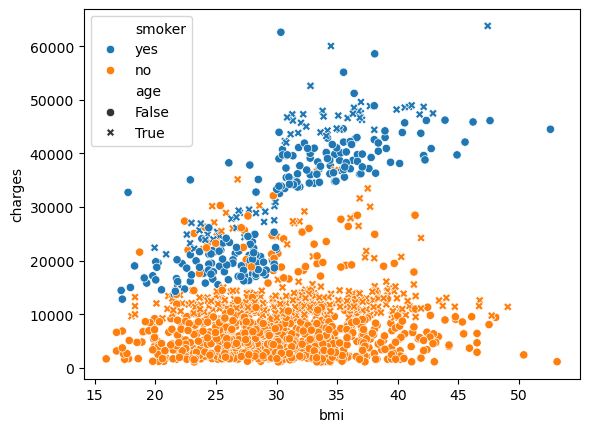

In [5]:
# 1. visualise the data first to see any patterns

sns.scatterplot(x = insurance_data["bmi"],y = insurance_data["charges"], hue = insurance_data["smoker"], style = insurance_data["age"]>50)

In [6]:
# 2. pre processing and feature engineering

# input values (remove charges col as it is the labels 
X = insurance_data.drop(columns = ["charges"]) # removing the charges col

# output values
y = insurance_data["charges"]

# one hot encoding
X = pd.get_dummies(X, columns=["region"],drop_first=True, dtype=int)

# encode sex and smoker columns
# sex = male (1) and female (0)
X["sex"] = X["sex"].map({
    "male" : 0,
    "female" : 1
})

# smoker = yes (1) and no (0)
X["smoker"] = X["smoker"].map({
    "yes" : 1,
    "no" : 0
})

# feature interaction

X["age_smoker"] = X["age"] * X["smoker"]
X["bmi_smoker"] = X["bmi"] * X["smoker"]

X.head()

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest,age_smoker,bmi_smoker
0,19,1,27.900,0,1,0,0,1,19,27.9
1,18,0,33.770,1,0,0,1,0,0,0.0
2,28,0,33.000,3,0,0,1,0,0,0.0
3,33,0,22.705,0,0,1,0,0,0,0.0
4,32,0,28.880,0,0,1,0,0,0,0.0


In [7]:
# 3. Train test split 

# divide X into 2 parts : X_train (80%) and X_test (20%)
# divide y into 2 parts : y_train (80%) and y_test (20%)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42) # test size = 20% and random_state decides the shuffling order (just keep it same)

X_train.head()

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest,age_smoker,bmi_smoker
560,46,1,19.95,2,0,1,0,0,0,0.0
1285,47,1,24.32,0,0,0,0,0,0,0.0
1142,52,1,24.86,0,0,0,1,0,0,0.0
969,39,1,34.32,5,0,0,1,0,0,0.0
486,54,1,21.47,3,0,1,0,0,0,0.0


In [8]:
# 4. Create and Train the model

from sklearn.linear_model import LinearRegression

# create model
model = LinearRegression()

# train model
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [9]:
# 5. predict values

y_predictions = model.predict(X_test)

In [10]:
# 6. Evaluate
from sklearn.metrics import r2_score

# a). R - squared 

r2 = r2_score(y_test,y_predictions) # pass true labels first, then the predicted labels
print(f"R - squared : {r2}")

# b). Adjusted R - squared

X_test.shape # tells us the shape of the test data which is 268, 5

n = X_test.shape[0] # 268
p = X_test.shape[1] # 5

adj_r2 = 1 - ( (1-r2) * (n-1) / (n-p-1) )
print(f"Adjusted R squared : {adj_r2}")

R - squared : 0.865231697953168
Adjusted R squared : 0.8599877951497893


In [16]:
# underfit & overfit
# r2 is low for both training and testing = underfit
# r2 for training >>>>>>>>> testing = overfit 

y_train_predictions = model.predict(X_train) # make predictions on the training data

r2_training = r2_score(y_train, y_train_predictions) # now the labels (answers) is the trainig set 

r2_training

0.8340713711218875